In [3]:

!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00


In [5]:
from google.colab import files
import pandas as pd

print("📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment")

uploaded = files.upload()

# Tạo biến chứa dataframe
df_jpm = df_bac = df_wfc = df_fed = df_spx = df_sentiment = None

for filename in uploaded.keys():

    print("Đã tải:", filename)

    if "JPM" in filename or "JP Morgan" in filename:
        df_jpm = pd.read_excel(filename)

    elif "BAC" in filename or "Bank of America" in filename:
        df_bac = pd.read_excel(filename)

    elif "WFC" in filename or "Wells Fargo " in filename:
        df_wfc = pd.read_excel(filename)

    elif "Lãi suất FED" in filename:
        df_fed = pd.read_excel(filename)

    elif "SPX500" in filename:
        df_spx = pd.read_excel(filename)

    elif "Sentiment" in filename:
        df_sentiment = pd.read_excel(filename)

# Kiểm tra đủ file chưa
required = {
    "JPM": df_jpm,
    "BAC": df_bac,
    "WFC": df_wfc,
    "FED": df_fed,
    "SPX": df_spx,
    "Sentiment": df_sentiment
}

missing = [name for name, df in required.items() if df is None]

if missing:
    print("\n❌ Thiếu file:", missing)
else:
    print("\n✅ Đã load đủ 6 file!")


📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment


Saving SPX500.csv.xlsx to SPX500.csv (1).xlsx
Saving Sentiment.xlsx to Sentiment (1).xlsx
Saving JP Morgan.xlsx to JP Morgan (1).xlsx
Saving Lãi suất FED.xlsx to Lãi suất FED (1).xlsx
Saving Wells Fargo.xlsx to Wells Fargo (1).xlsx
Saving Bank of America.xlsx to Bank of America (1).xlsx
Đã tải: SPX500.csv (1).xlsx
Đã tải: Sentiment (1).xlsx
Đã tải: JP Morgan (1).xlsx
Đã tải: Lãi suất FED (1).xlsx
Đã tải: Wells Fargo (1).xlsx
Đã tải: Bank of America (1).xlsx

✅ Đã load đủ 6 file!


In [7]:


print("🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...")

# --- 1. HÀM CHUẨN HÓA NGÀY THÁNG ---
def clean_date(df):
    # Xóa khoảng trắng thừa ở tên cột
    df.columns = df.columns.str.strip()
    # Tìm cột Date
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date']).dt.normalize() # Xóa giờ phút giây
    return df

# --- 2. ĐỌC DỮ LIỆU TỪ FILE ---
try:
    # A. Dữ liệu Vĩ mô & Tin tức
    fed = pd.read_excel('Lãi suất FED (1).xlsx')
    sentiment = pd.read_excel('Sentiment (1).xlsx')
    spx = pd.read_excel('SPX500.csv (1).xlsx')

    # B. Dữ liệu 3 Cổ phiếu
    jpm = pd.read_excel('JP Morgan (1).xlsx')
    wfc = pd.read_excel('Wells Fargo (1).xlsx')
    bac = pd.read_excel('Bank of America (1).xlsx')

    print("   -> Đã đọc xong 6 file Excel.")

except FileNotFoundError:
    print("❌ LỖI: Không tìm thấy file. Hãy đảm bảo bạn đã upload đủ 6 file và đúng tên.")
    # Dừng chương trình nếu thiếu file
    raise

# --- 3. LÀM SẠCH CHI TIẾT ---

# A. Chuẩn hóa ngày tháng cho tất cả
fed = clean_date(fed)
sentiment = clean_date(sentiment)
spx = clean_date(spx)
jpm = clean_date(jpm)
wfc = clean_date(wfc)
bac = clean_date(bac)

# B. Xử lý file Lãi suất FED (Thường hay bị lỗi định dạng text)
# Ép cột EFFR sang số, nếu lỗi biến thành NaN
fed['EFFR'] = pd.to_numeric(fed['EFFR'], errors='coerce')
# Sắp xếp theo ngày
fed = fed.sort_values('Date')
# Lấp đầy lãi suất (Forward Fill - Lãi suất hôm nay = hôm qua nếu ko có dữ liệu)
fed['EFFR'] = fed['EFFR'].ffill()

# C. Đổi tên cột để tránh trùng lặp khi gộp
# Chỉ giữ lại cột Date, Close và Volume (nếu cần)
spx = spx[['Date', 'Close']].rename(columns={'Close': 'SPX_Close'})

jpm = jpm[['Date', 'Close']].rename(columns={'Close': 'JPM_Close'})
wfc = wfc[['Date', 'Close']].rename(columns={'Close': 'WFC_Close'})
bac = bac[['Date', 'Close']].rename(columns={'Close': 'BAC_Close'})

# --- 4. HỢP NHẤT DỮ LIỆU (MERGE) ---
print("🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...")

# Lấy SPX làm khung xương (Backbone) vì chỉ số thị trường có lịch giao dịch chuẩn nhất
master_df = spx

# Gộp lần lượt các cổ phiếu vào (Left Join theo ngày)
master_df = master_df.merge(jpm, on='Date', how='left')
master_df = master_df.merge(wfc, on='Date', how='left')
master_df = master_df.merge(bac, on='Date', how='left')

# Gộp thông tin vĩ mô (FED) và Tin tức (Sentiment)
master_df = master_df.merge(fed[['Date', 'EFFR']], on='Date', how='left')
master_df = master_df.merge(sentiment, on='Date', how='left')

# --- 5. XỬ LÝ SAU KHI GỘP ---
# A. Lấp đầy dữ liệu FED cho những ngày cuối tuần/nghỉ lễ nếu bị hổng
master_df['EFFR'] = master_df['EFFR'].ffill()

# B. Xử lý Sentiment bị thiếu (NaN -> 0)
# Tìm các cột sentiment tự động
sent_cols = [c for c in master_df.columns if 'sentiment' in c or 'news_count' in c]
master_df[sent_cols] = master_df[sent_cols].fillna(0)

# C. Loại bỏ những ngày không giao dịch (Cả 3 cổ phiếu đều NaN)
stock_cols = ['JPM_Close', 'WFC_Close', 'BAC_Close']
master_df = master_df.dropna(subset=stock_cols, how='all').reset_index(drop=True)

# Kiểm tra kết quả
print(f"✅ HOÀN TẤT! Master DataFrame có kích thước: {master_df.shape}")
print("   -> Sẵn sàng cho bước dự báo.")
print("-" * 60)
print(master_df.head())

🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...
   -> Đã đọc xong 6 file Excel.
🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...
✅ HOÀN TẤT! Master DataFrame có kích thước: (1977, 12)
   -> Sẵn sàng cho bước dự báo.
------------------------------------------------------------
        Date    SPX_Close  JPM_Close  WFC_Close  BAC_Close  EFFR  \
0 2018-01-02  2695.810059     107.95      61.09      29.90  1.42   
1 2018-01-03  2713.060059     108.06      61.56      29.80  1.42   
2 2018-01-04  2723.989990     109.04      62.33      30.19  1.42   
3 2018-01-05  2743.149902     108.34      62.75      30.33  1.42   
4 2018-01-08  2747.709961     108.50      62.04      30.12  1.91   

   BAC_news_count  JPM_news_count  WFC_news_count  BAC_avg_sentiment  \
0             0.0             0.0             0.0                0.0   
1             0.0             0.0             0.0                0.0   
2             0.0             0.0             0.0                0.0   
3             0.0             0.0      

In [12]:
import pandas as pd

def merge_stock(df_stock, df_fed, df_spx, df_sentiment, ticker):
    # Tạo bản sao
    df_stock = df_stock.copy()
    df_fed = df_fed.copy()
    df_spx = df_spx.copy()
    df_sentiment = df_sentiment.copy()

    # --- SỬA LỖI QUAN TRỌNG: CẮT BỎ GIỜ PHÚT ---
    # .dt.normalize() sẽ đưa 16:00:00 về 00:00:00 để khớp với các file kia
    df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.normalize()
    df_fed['Date'] = pd.to_datetime(df_fed['Date']).dt.normalize()
    df_spx['Date'] = pd.to_datetime(df_spx['Date']).dt.normalize()
    df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date']).dt.normalize()
    # -------------------------------------------

    # Đổi tên cột Close của SPX để tránh trùng
    if 'Close' in df_spx.columns:
        df_spx = df_spx.rename(columns={'Close': 'SPX_Close'})

    # Chỉ lấy cột Date và Close của SPX để bảng gọn gàng hơn, tránh dư cột _x, _y
    df_spx_clean = df_spx[['Date', 'SPX_Close']] if 'SPX_Close' in df_spx.columns else df_spx

    # Merge lần lượt (Left Join)
    df_merge = df_stock.merge(df_fed, on='Date', how='left')
    df_merge = df_merge.merge(df_spx_clean, on='Date', how='left')

    # Xử lý Sentiment
    sent_col = f'{ticker}_avg_sentiment'
    if sent_col in df_sentiment.columns:
        df_merge = df_merge.merge(df_sentiment[['Date', sent_col]], on='Date', how='left')
    else:
        print(f"⚠️ Không tìm thấy cột sentiment cho {ticker}, tự động điền 0.")
        df_merge[sent_col] = 0

    # Fill NaN (Lấp đầy dữ liệu trống)
    for col in df_merge.columns:
        if col != 'Date':
            df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')
            df_merge[col] = df_merge[col].ffill().bfill() # Lấp xuôi rồi lấp ngược

            # Nếu vẫn còn NaN (do file ngoại sinh thiếu dữ liệu đầu/cuối), điền 0 hoặc giá trị trung bình
            df_merge[col] = df_merge[col].fillna(0)

    # Sắp xếp theo ngày
    df_merge = df_merge.sort_values('Date').reset_index(drop=True)

    return df_merge

# --- CHẠY LẠI ---
print("⏳ Đang thực hiện Merge lại (đã xử lý giờ phút)...")
df_jpm_merge = merge_stock(df_jpm, df_fed, df_spx, df_sentiment, 'JPM')
df_bac_merge = merge_stock(df_bac, df_fed, df_spx, df_sentiment, 'BAC')
df_wfc_merge = merge_stock(df_wfc, df_fed, df_spx, df_sentiment, 'WFC')

# --- KIỂM TRA KỸ ---
print("\n✅ Dữ liệu JPM sau khi sửa:")
print(df_jpm_merge[['Date', 'Close', 'EFFR', 'SPX_Close', 'JPM_avg_sentiment']].head())

# Kiểm tra xem còn NaN không
nan_count = df_jpm_merge['EFFR'].isna().sum()
print(f"\nSố lượng dòng bị lỗi NaN trong cột Lãi suất (EFFR): {nan_count}")
if nan_count == 0:
    print("🎉 Dữ liệu đã sạch 100%! Bạn có thể chạy mô hình Expanding Window ngay.")
else:
    print("⚠️ Vẫn còn lỗi NaN, hãy kiểm tra lại file Lãi suất.")

⏳ Đang thực hiện Merge lại (đã xử lý giờ phút)...

✅ Dữ liệu JPM sau khi sửa:
        Date   Close  EFFR    SPX_Close  JPM_avg_sentiment
0 2018-01-02  107.95  1.42  2695.810059                0.0
1 2018-01-03  108.06  1.42  2713.060059                0.0
2 2018-01-04  109.04  1.42  2723.989990                0.0
3 2018-01-05  108.34  1.42  2743.149902                0.0
4 2018-01-08  108.50  1.91  2747.709961                0.0

Số lượng dòng bị lỗi NaN trong cột Lãi suất (EFFR): 0
🎉 Dữ liệu đã sạch 100%! Bạn có thể chạy mô hình Expanding Window ngay.



🛡️ --- ARIMAX ROLLING (LOG-TRANSFORM + SANITY CHECK): JPM ---
-> Đang tìm tham số tối ưu trên dữ liệu Log...
-> Tham số (trên Log): (0, 1, 0)
-> Bắt đầu trượt cửa sổ...


100%|██████████| 1477/1477 [07:47<00:00,  3.16it/s]


✅ KẾT QUẢ ĐÃ SỬA LỖI: RMSE=2.24 | MAPE=1.00%


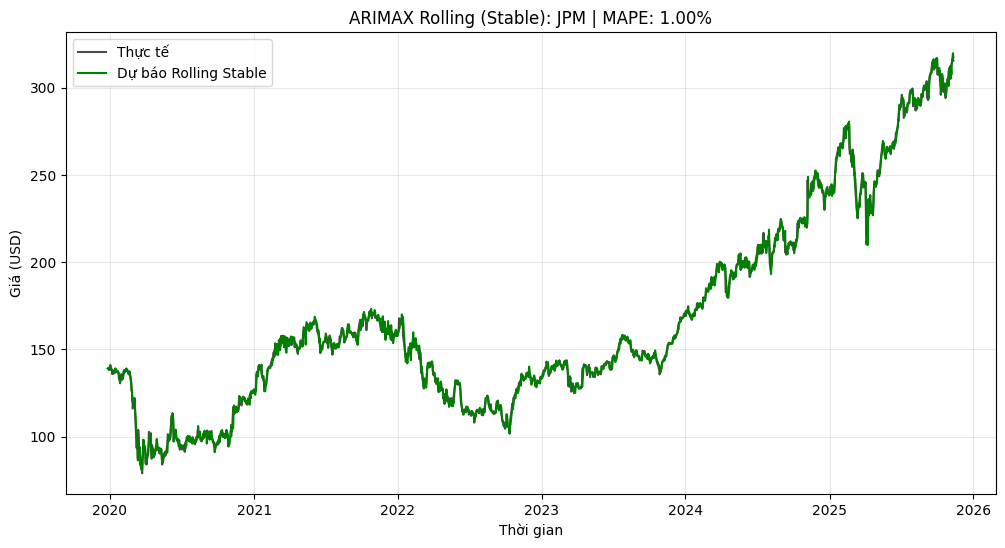


🛡️ --- ARIMAX ROLLING (LOG-TRANSFORM + SANITY CHECK): BAC ---
-> Đang tìm tham số tối ưu trên dữ liệu Log...
-> Tham số (trên Log): (0, 1, 0)
-> Bắt đầu trượt cửa sổ...


100%|██████████| 1477/1477 [07:50<00:00,  3.14it/s]

✅ KẾT QUẢ ĐÃ SỬA LỖI: RMSE=0.57 | MAPE=1.16%


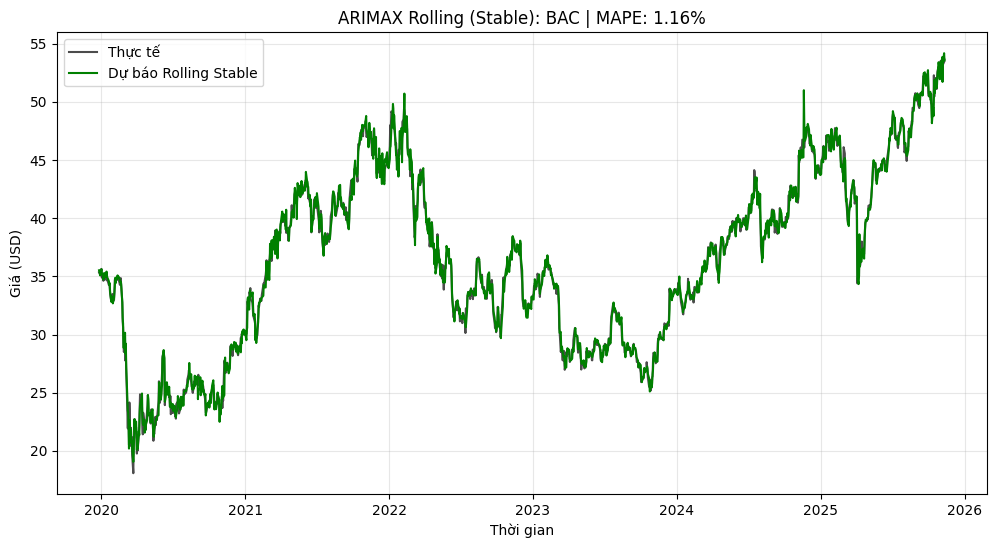


🛡️ --- ARIMAX ROLLING (LOG-TRANSFORM + SANITY CHECK): WFC ---
-> Đang tìm tham số tối ưu trên dữ liệu Log...
-> Tham số (trên Log): (0, 1, 0)
-> Bắt đầu trượt cửa sổ...


100%|██████████| 1475/1475 [07:28<00:00,  3.29it/s]


✅ KẾT QUẢ ĐÃ SỬA LỖI: RMSE=0.90 | MAPE=1.35%


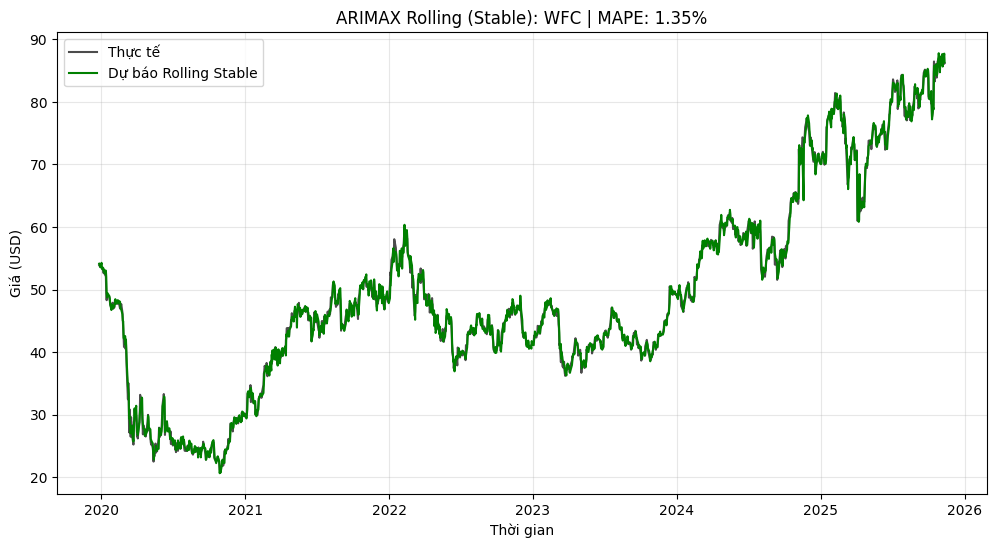

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pmdarima as pm
from tqdm import tqdm
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

def run_arimax_rolling_stable(df, ticker, window_size=500):
    print(f"\n🛡️ --- ARIMAX ROLLING (LOG-TRANSFORM + SANITY CHECK): {ticker} ---")

    # 1. Cấu hình & Log Transform
    target_col = 'Close'
    exog_cols = ['EFFR', 'SPX_Close', f'{ticker}_avg_sentiment']

    data = df.reset_index(drop=True)

    # --- BƯỚC 1: CHUYỂN GIÁ VỀ LOG ĐỂ ỔN ĐỊNH ---
    # Logarit giúp giảm độ biến động và ngăn chặn số âm
    data['Log_Close'] = np.log(data[target_col])

    n_obs = len(data)

    # 2. Tìm tham số trên dữ liệu LOG
    print("-> Đang tìm tham số tối ưu trên dữ liệu Log...")
    initial_window = data.iloc[:window_size]

    model_auto = pm.auto_arima(initial_window['Log_Close'], exogenous=initial_window[exog_cols],
                               seasonal=False, stepwise=True,
                               suppress_warnings=True, error_action="ignore")
    order = model_auto.order
    print(f"-> Tham số (trên Log): {order}")

    # 3. Vòng lặp Rolling
    predictions = []
    actuals = []
    dates_test = []

    print("-> Bắt đầu trượt cửa sổ...")

    # Biến lưu giá hôm trước để làm Sanity Check
    prev_price = data[target_col].iloc[window_size-1]

    for t in tqdm(range(window_size, n_obs)):
        # A. Cắt dữ liệu (Train window)
        start_idx = t - window_size
        end_idx = t

        train_endog = data['Log_Close'].iloc[start_idx:end_idx] # Dùng Log
        train_exog = data[exog_cols].iloc[start_idx:end_idx]

        # B. Huấn luyện lại
        try:
            model = ARIMA(endog=train_endog, exog=train_exog, order=order)
            model_fit = model.fit()

            # C. Dự báo Log
            next_exog = data[exog_cols].iloc[t].values.reshape(1, -1)
            forecast_result = model_fit.forecast(steps=1, exog=next_exog)

            if isinstance(forecast_result, pd.Series):
                pred_log = forecast_result.iloc[0]
            else:
                pred_log = forecast_result[0]

            # --- BƯỚC 2: CHUYỂN NGƯỢC TỪ LOG VỀ GIÁ THỰC ---
            pred_price = np.exp(pred_log)

            # --- BƯỚC 3: SANITY CHECK (KIỂM TRA ĐIÊN RỒ) ---
            # Nếu giá dự báo biến động quá 20% so với ngày hôm trước -> Coi là lỗi mô hình
            # Thay thế bằng giá ngày hôm trước (No change)
            pct_change = abs(pred_price - prev_price) / prev_price

            if pct_change > 0.20: # Lớn hơn 20%
                # print(f"⚠️ Phát hiện bất thường tại index {t}: Dự báo {pred_price:.2f} vs Trước đó {prev_price:.2f}. Đã sửa.")
                pred_price = prev_price

        except Exception as e:
            # Nếu mô hình lỗi hẳn (không hội tụ), dùng giá hôm trước
            pred_price = prev_price

        predictions.append(pred_price)

        # Cập nhật giá thực tế cho vòng lặp sau
        actual_val = data[target_col].iloc[t]
        actuals.append(actual_val)
        dates_test.append(df['Date'].iloc[t])

        prev_price = actual_val # Cập nhật giá tham chiếu

    # 4. Đánh giá
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = mean_absolute_percentage_error(actuals, predictions)

    print(f"✅ KẾT QUẢ ĐÃ SỬA LỖI: RMSE={rmse:.2f} | MAPE={mape:.2%}")

    # 5. Vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    plt.plot(dates_test, actuals, label='Thực tế', color='black', alpha=0.7)
    plt.plot(dates_test, predictions, label=f'Dự báo Rolling Stable', color='green', linestyle='-', linewidth=1.5)
    plt.title(f'ARIMAX Rolling (Stable): {ticker} | MAPE: {mape:.2%}')
    plt.xlabel('Thời gian')
    plt.ylabel('Giá (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- CHẠY LẠI CHO CẢ 3 MÃ (ĐỂ ĐẢM BẢO KHÔNG CÁI NÀO BỊ LỖI NỮA) ---
run_arimax_rolling_stable(df_jpm_merge, 'JPM', window_size=500)
run_arimax_rolling_stable(df_bac_merge, 'BAC', window_size=500)
run_arimax_rolling_stable(df_wfc_merge, 'WFC', window_size=500)